In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [2]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               341 non-null    object 
 1   Step                    341 non-null    object 
 2   Input Tokens (Prompt)   341 non-null    int64  
 3   Output Tokens (Answer)  341 non-null    int64  
 4   Total Tokens            341 non-null    int64  
 5   Latency (s)             341 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 16.1+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,341.000000,341.000000,341.000000,341.000000
mean,8622.586510,200.478006,9537.299120,3.645279
std,11111.249447,474.100768,12472.901475,7.545756
min,477.000000,3.000000,640.000000,0.590000
25%,754.000000,15.000000,1078.000000,0.930000
50%,1272.000000,72.000000,1868.000000,1.360000
75%,26101.000000,288.000000,26398.000000,4.510000
max,34670.000000,7611.000000,55642.000000,81.070000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79


In [3]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'FRB' if '_FRB' in x else 'HRB')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28,0,HRB
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67,775,HRB
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82,0,HRB
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33,192,FRB
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79,0,FRB


In [4]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_FRB,FRB,1329.340909,61.045455,0.045455,1390.431818
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024
2,Evaluator_Naive,Naive,27407.093023,57.883721,0.279070,27465.255814
3,Generator_FRB,FRB,954.568182,463.568182,523.772727,1941.909091
4,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878
5,Generator_Naive,Naive,26867.348837,494.674419,4646.534884,32008.558140
6,Router_FRB,FRB,747.931818,12.795455,1.818182,762.545455
7,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927


,Step,Model,Latency
0,Evaluator_FRB,FRB,1.015455
1,Evaluator_HRB,HRB,1.008293
2,Evaluator_Naive,Naive,3.149302
3,Generator_FRB,FRB,5.674091
4,Generator_HRB,HRB,5.944390
5,Generator_Naive,Naive,10.400698
6,Router_FRB,FRB,0.888182
7,Router_HRB,HRB,1.022195


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,FRB,3031.840909,537.409091,525.636364,4094.886364
1,HRB,11539.024390,511.146341,502.756098,12552.926829
2,Naive,54274.441860,552.558140,4646.813953,59473.813953


,Model,Latency
0,FRB,7.577727
1,HRB,7.974878
2,Naive,13.550000


In [5]:
model_analysis = model_token_usage_df.merge(model_time_usage_df.set_index('Model'), left_on='Model', right_index=True)
display(model_analysis)

step_analysis = step_token_usage_df.merge(step_time_usage_df.set_index('Step'), left_on='Step', right_index=True)
display(step_analysis)

model_analysis.to_csv('analysis/model_analysis.csv', index=False)
step_analysis.to_csv('analysis/step_analysis.csv', index=False)

,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,FRB,3031.840909,537.409091,525.636364,4094.886364,7.577727
1,HRB,11539.024390,511.146341,502.756098,12552.926829,7.974878
2,Naive,54274.441860,552.558140,4646.813953,59473.813953,13.550000


,Step,Model_x,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Model_y,Latency
0,Evaluator_FRB,FRB,1329.340909,61.045455,0.045455,1390.431818,FRB,1.015455
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024,HRB,1.008293
2,Evaluator_Naive,Naive,27407.093023,57.883721,0.279070,27465.255814,Naive,3.149302
3,Generator_FRB,FRB,954.568182,463.568182,523.772727,1941.909091,FRB,5.674091
4,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878,HRB,5.944390
5,Generator_Naive,Naive,26867.348837,494.674419,4646.534884,32008.558140,Naive,10.400698
6,Router_FRB,FRB,747.931818,12.795455,1.818182,762.545455,FRB,0.888182
7,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,HRB,1.022195


In [6]:
chat_df = pd.read_csv('chat_logs.csv')
topic_subtopic_per_architecture_df = chat_df.groupby('Architecture').agg({
    'Topic_Count': 'mean',
    'Subtopic_Count': 'mean'
}).reset_index()

display(topic_subtopic_per_architecture_df)
chat_df.to_csv('analysis/chat_analysis.csv', index=False)

,Architecture,Topic_Count,Subtopic_Count
0,FRB,2.125000,14.950000
1,HRB,1.307692,9.358974
2,Naive,117.767442,1029.976744


## Plots

### Cmap

In [7]:
# Colormap for each Step category

FRB = "#1F77B4"
HRB = "#328F3A"
full_db = "#f93e3e"

step_cmap = {
    'Router_FRB': FRB,
    'Generator_FRB': FRB,
    'Evaluator_FRB': FRB,

    'Router_HRB': HRB,
    'Generator_HRB': HRB,
    'Evaluator_HRB': HRB,

    'Generator_Naive': full_db,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'FRB': FRB,
    'HRB': HRB,
    'Naive': full_db
}

### Comparison

#### Average token per model

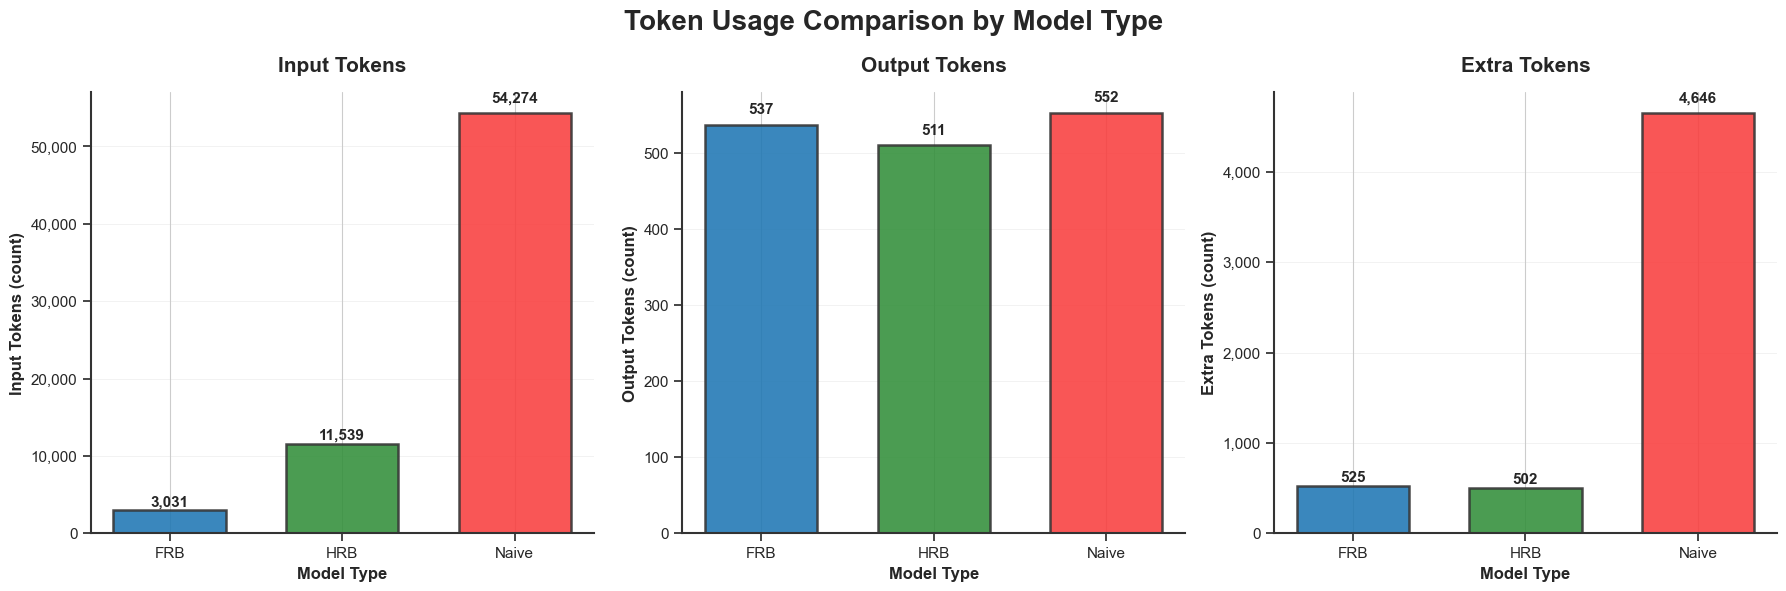

In [8]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='#333333', linewidth=1.8, alpha=0.88, width=0.65)
    
    ax.set_title(f'{metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(f'{metric} (count)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
    ax.tick_params(axis='y', which='minor', labelsize=10)
    
    # Format y-axis with thousand separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Add value labels on bars with better formatting
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

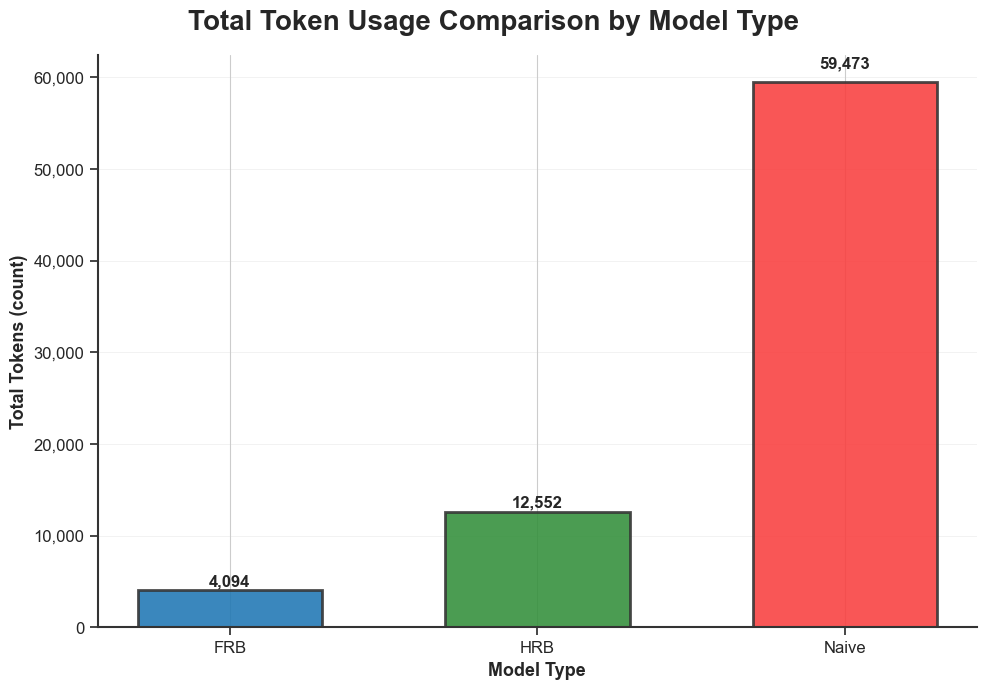

In [9]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Tokens (count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        #family='serif'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

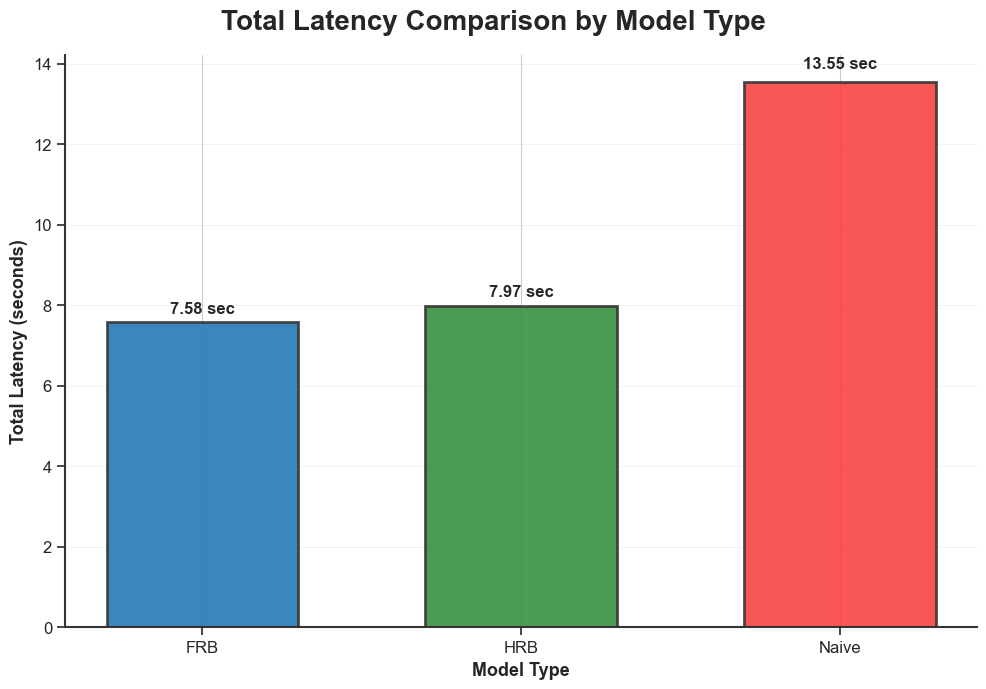

In [10]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{height:.2f} sec',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

In [11]:
print(df['Step'].value_counts())
print('\n')
print(df['Model'].value_counts())

Step
Generator_FRB      44
Evaluator_FRB      44
Router_FRB         44
Generator_Naive    43
Evaluator_Naive    43
Router_HRB         41
Generator_HRB      41
Evaluator_HRB      41
Name: count, dtype: int64


Model
FRB      132
HRB      123
Naive     86
Name: count, dtype: int64


In [12]:
router_usage_df = df[df['Step'].str.contains('Router')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(router_usage_df)
router_usage_df.to_csv('analysis/router_usage.csv', index=False)
router_usage_df = router_usage_df.merge(topic_subtopic_per_architecture_df.set_index('Architecture'), left_on='Model', right_index=True)
display(router_usage_df)

generator_usage_df = df[df['Step'].str.contains('Generator')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(generator_usage_df)
generator_usage_df.to_csv('analysis/generator_usage.csv', index=False)

evaluator_usage_df = df[df['Step'].str.contains('Evaluator')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(evaluator_usage_df)
evaluator_usage_df.to_csv('analysis/evaluator_usage.csv', index=False)


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Router_FRB,FRB,747.931818,12.795455,1.818182,762.545455,0.888182
1,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,1.022195


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency,Topic_Count,Subtopic_Count
0,Router_FRB,FRB,747.931818,12.795455,1.818182,762.545455,0.888182,2.125000,14.950000
1,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,1.022195,1.307692,9.358974


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Generator_FRB,FRB,954.568182,463.568182,523.772727,1941.909091,5.674091
1,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878,5.944390
2,Generator_Naive,Naive,26867.348837,494.674419,4646.534884,32008.558140,10.400698


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Evaluator_FRB,FRB,1329.340909,61.045455,0.045455,1390.431818,1.015455
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024,1.008293
2,Evaluator_Naive,Naive,27407.093023,57.883721,0.279070,27465.255814,3.149302


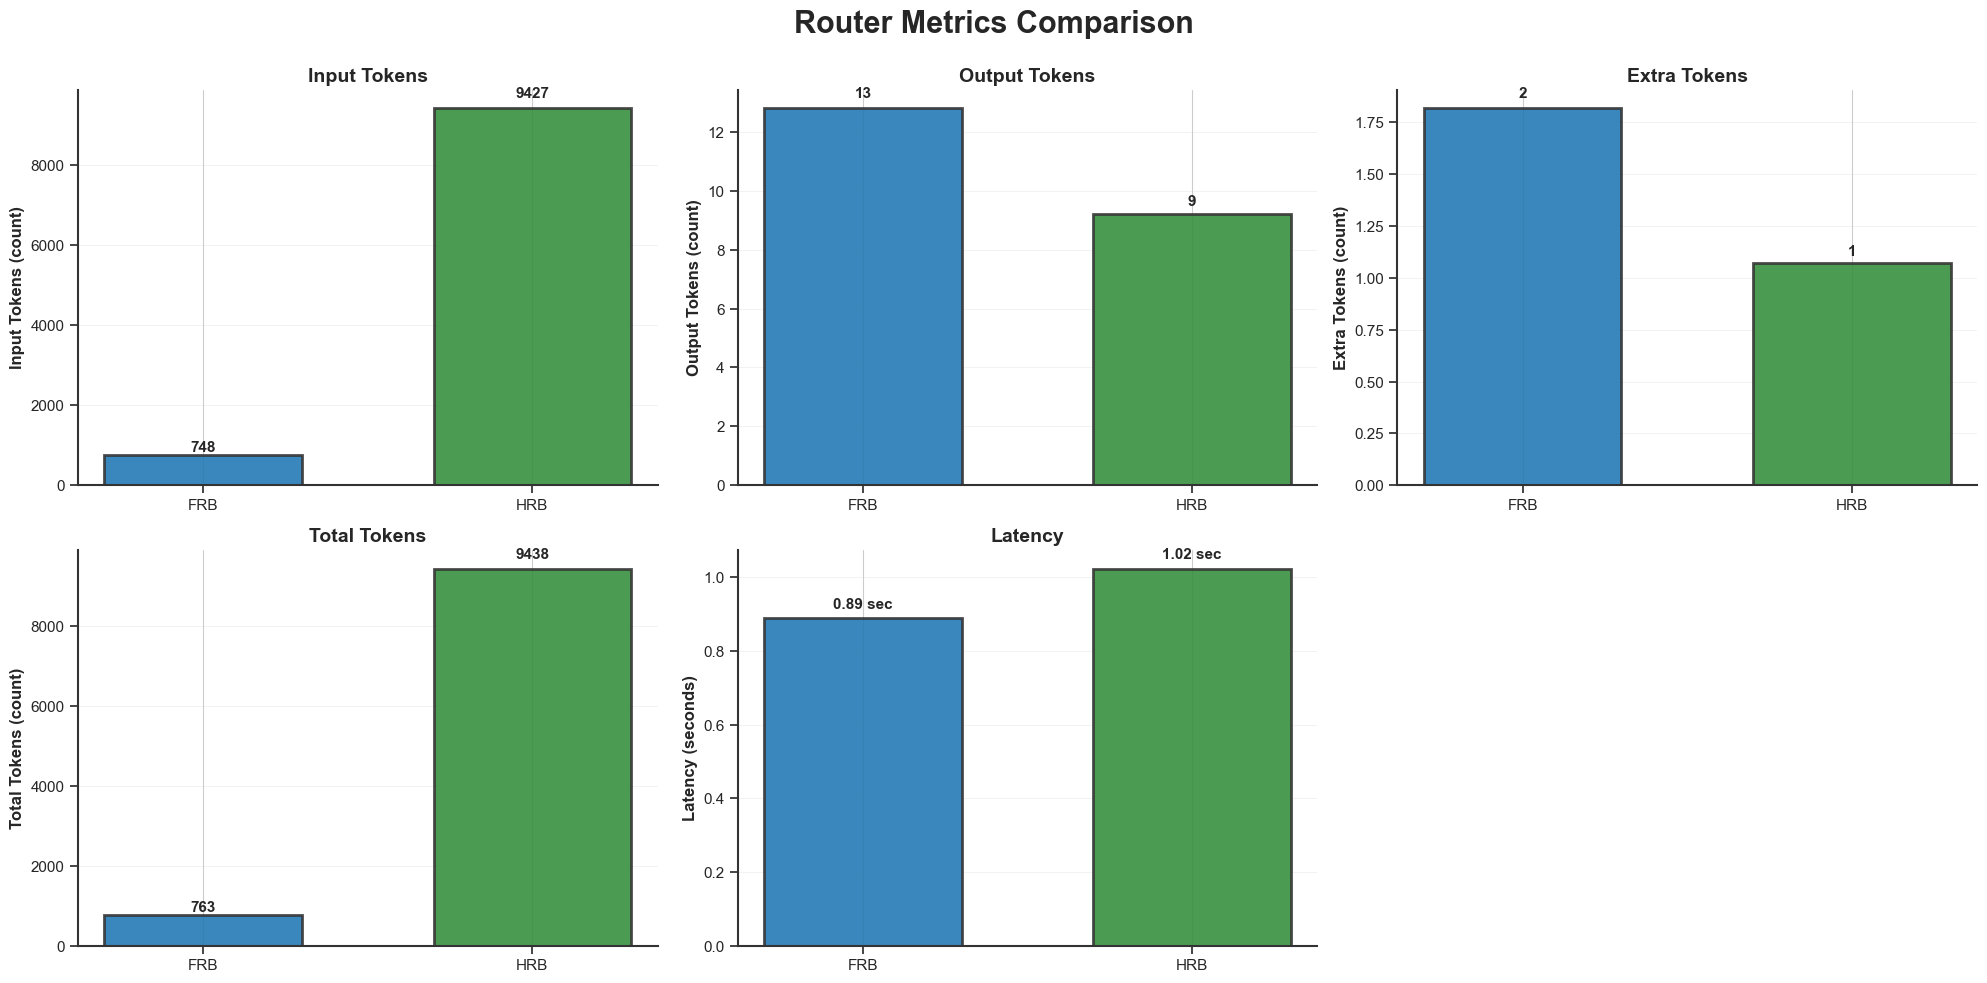

In [13]:
import matplotlib.pyplot as plt

# Assuming router_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Router Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        router_usage_df['Model'],
        router_usage_df[metric],
        color=[model_cmap[model] for model in router_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

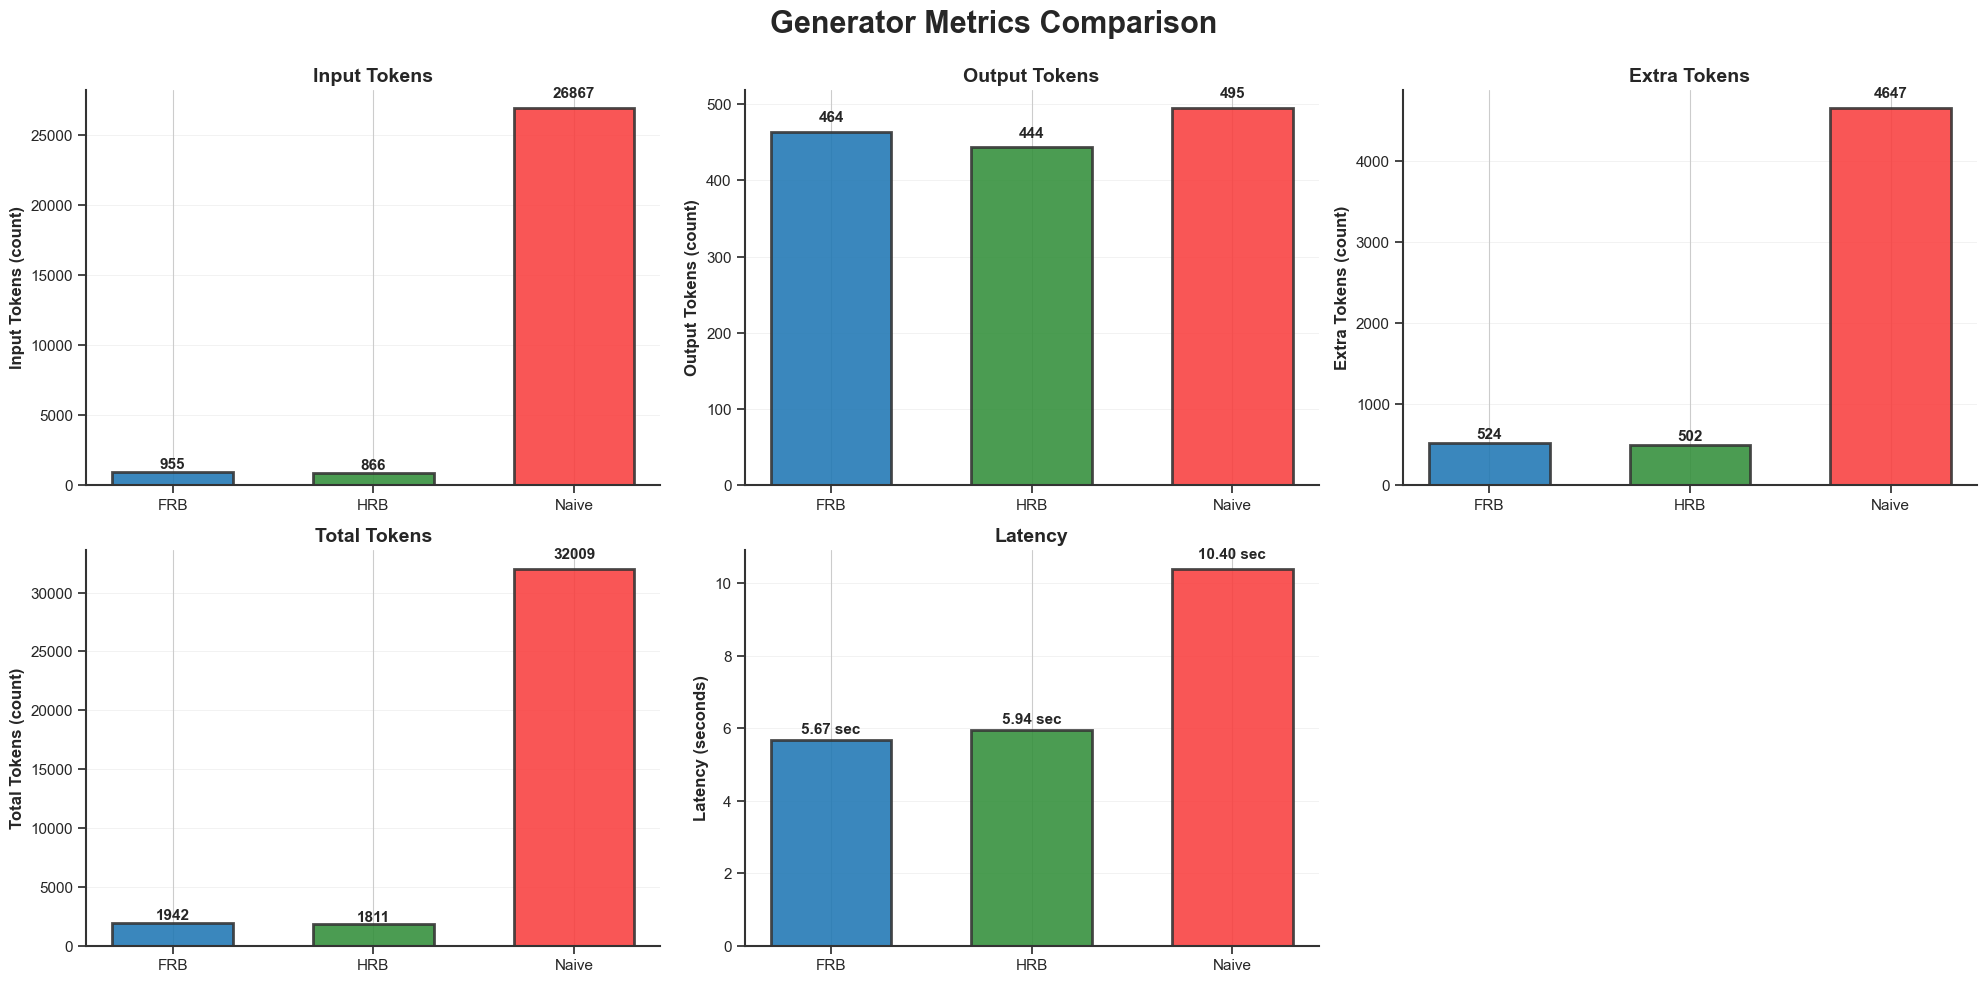

In [14]:
# Assuming router_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Generator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        generator_usage_df['Model'],
        generator_usage_df[metric],
        color=[model_cmap[model] for model in generator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

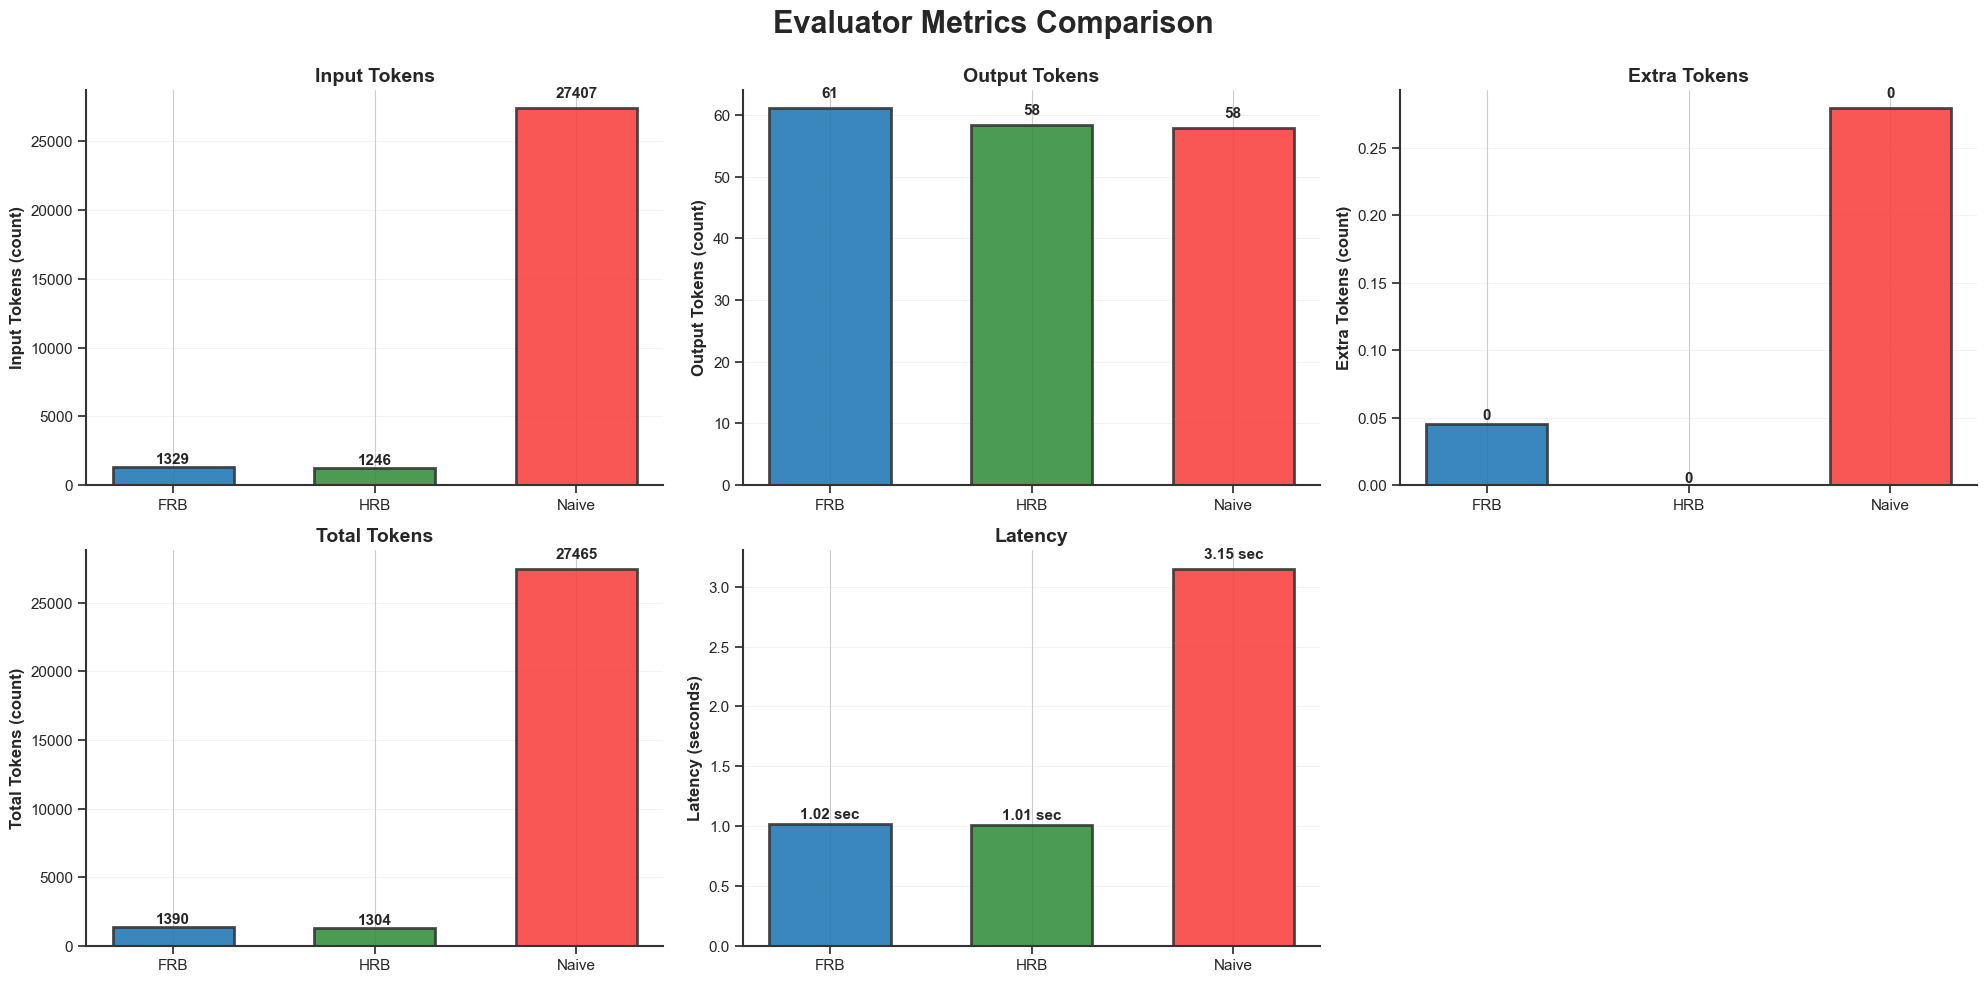

In [15]:
import matplotlib.pyplot as plt

# Assuming evaluator_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Evaluator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        evaluator_usage_df['Model'],
        evaluator_usage_df[metric],
        color=[model_cmap[model] for model in evaluator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# Chat-Log Analysis